## Lab 2
### Part 2: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recomment to use Google Colab or other machine with GPU acceleration.

In [15]:
!pip install torchsummary

In [16]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

In [17]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print('Directory', path, 'is created!')
    else:
        print('Directory', path, 'already exists!')

root_path = 'fmnist'
mkdir(root_path)

Directory fmnist already exists!


In [18]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(root_path,
                                                        train=True,
                                                        transform=train_transform,
                                                        target_transform=None,
                                                        download=download)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(root_path,
                                                       train=False,
                                                       transform=test_transform,
                                                       target_transform=None,
                                                       download=download)

In [19]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train,
                                           batch_size=128,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=256,
                                          shuffle=False,
                                          num_workers=2)

In [20]:
len(fmnist_dataset_test)

10000

In [21]:
for img, label in train_loader:
    print(img.shape)
#     print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])
128


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [22]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here

            nn.Linear(input_shape, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [23]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
       BatchNorm1d-3                  [-1, 512]           1,024
              ReLU-4                  [-1, 512]               0
            Linear-5                  [-1, 256]         131,328
       BatchNorm1d-6                  [-1, 256]             512
              ReLU-7                  [-1, 256]               0
            Linear-8                  [-1, 128]          32,896
       BatchNorm1d-9                  [-1, 128]             256
             ReLU-10                  [-1, 128]               0
           Linear-11                   [-1, 10]           1,290
Total params: 569,226
Trainable params: 569,226
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

Your experiments come here:

In [24]:
def train_epoch(model, loader, optimizer, loss_func, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), correct / total

def evaluate(model, loader, loss_func, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_func(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), correct / total

Epoch 1/20: Train Loss: 0.4473, Train Acc: 0.8425, Test Loss: 0.3849, Test Acc: 0.8593
Epoch 2/20: Train Loss: 0.3279, Train Acc: 0.8806, Test Loss: 0.3812, Test Acc: 0.8574
Epoch 3/20: Train Loss: 0.2921, Train Acc: 0.8913, Test Loss: 0.3178, Test Acc: 0.8806
Epoch 4/20: Train Loss: 0.2624, Train Acc: 0.9011, Test Loss: 0.3452, Test Acc: 0.8756
Epoch 5/20: Train Loss: 0.2437, Train Acc: 0.9087, Test Loss: 0.3795, Test Acc: 0.8576
Epoch 6/20: Train Loss: 0.2263, Train Acc: 0.9143, Test Loss: 0.3679, Test Acc: 0.8716
Epoch 7/20: Train Loss: 0.2109, Train Acc: 0.9203, Test Loss: 0.3247, Test Acc: 0.8838
Epoch 8/20: Train Loss: 0.1960, Train Acc: 0.9264, Test Loss: 0.2973, Test Acc: 0.8936
Epoch 9/20: Train Loss: 0.1807, Train Acc: 0.9324, Test Loss: 0.3381, Test Acc: 0.8867
Epoch 10/20: Train Loss: 0.1712, Train Acc: 0.9354, Test Loss: 0.3263, Test Acc: 0.8844
Epoch 11/20: Train Loss: 0.1585, Train Acc: 0.9385, Test Loss: 0.3197, Test Acc: 0.8916
Epoch 12/20: Train Loss: 0.1493, Train Ac

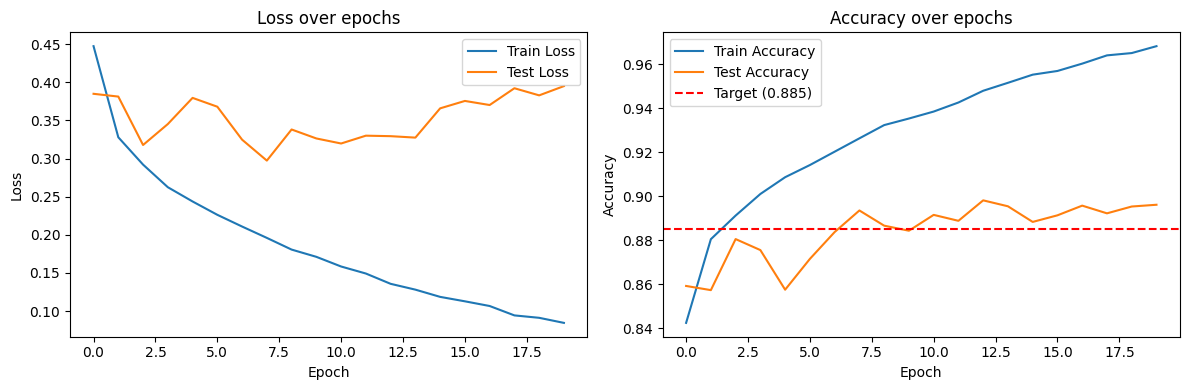

In [25]:
model = TinyNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001) # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss() # YOUR CODE HERE

# Your experiments, training and validation loops here


train_losses, test_losses = [], []
train_accs, test_accs = [], []

num_epochs = 20

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, opt, loss_func, device)
    #train_loss, train_acc = train_epoch(model_of, train_loader_small, opt_of, loss_func, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_func, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}: '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
          f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

print(f'\nFinal Test Accuracy: {test_accs[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over epochs')
axes[0].legend()

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(test_accs, label='Test Accuracy')
axes[1].axhline(y=0.885, color='r', linestyle='--', label='Target (0.885)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

<font color = darkblue>
Что видно на графиках:

- <font color = darkblue>цель получить точность 0.885 достигнута;</font>
- <font color = darkblue>train Loss стабильно падает;</font>
- <font color = darkblue>train Accuracy растёт до ~97%, test Accuracy достигает ~89-90% и стабилизируется</font>

Видны признаки переобучения: train Loss продолжает падать, а test Loss начинает расти после ~8 эпохи
</font>

### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accurasy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [50]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here

            # nn.Linear(input_shape, 4096),
            # nn.ReLU(),

            # nn.Linear(4096, 2048),
            # nn.ReLU(),

            # nn.Linear(2048, 512),
            # nn.ReLU(),

            nn.Linear(input_shape, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out


In [51]:
# Посмотрим количество параметров
model_overfit = OverfittingNeuralNetwork().to(device)
total_params = sum(p.numel() for p in model_overfit.parameters())
print(f"Total parameters: {total_params:,}")  # ~4.5 млн

torchsummary.summary(model_overfit, (28*28,))

#torchsummary.summary(OverfittingNeuralNetwork().to(device), (28*28,))

Total parameters: 4,627,210
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 2048]       1,607,680
              ReLU-3                 [-1, 2048]               0
            Linear-4                 [-1, 1024]       2,098,176
              ReLU-5                 [-1, 1024]               0
            Linear-6                  [-1, 512]         524,800
              ReLU-7                  [-1, 512]               0
            Linear-8                  [-1, 512]         262,656
              ReLU-9                  [-1, 512]               0
           Linear-10                  [-1, 256]         131,328
             ReLU-11                  [-1, 256]               0
           Linear-12                   [-1, 10]           2,570
Total params: 4,627,210
Trainable params: 4,627,210
Non-trainable params: 0

Train subset size: 5000
Test set size: 10000
Epoch 10/50: Train Loss: 0.3312, Train Acc: 0.8774, Test Loss: 0.7001, Test Acc: 0.7870
Epoch 20/50: Train Loss: 0.2057, Train Acc: 0.9210, Test Loss: 0.5628, Test Acc: 0.8446
Epoch 30/50: Train Loss: 0.1517, Train Acc: 0.9436, Test Loss: 0.6470, Test Acc: 0.8408
Epoch 40/50: Train Loss: 0.1020, Train Acc: 0.9642, Test Loss: 0.7589, Test Acc: 0.8421
Epoch 50/50: Train Loss: 0.1345, Train Acc: 0.9552, Test Loss: 0.7622, Test Acc: 0.8301

Final Train Accuracy: 0.9552
Final Test Accuracy: 0.8301
Overfitting gap: 0.1251


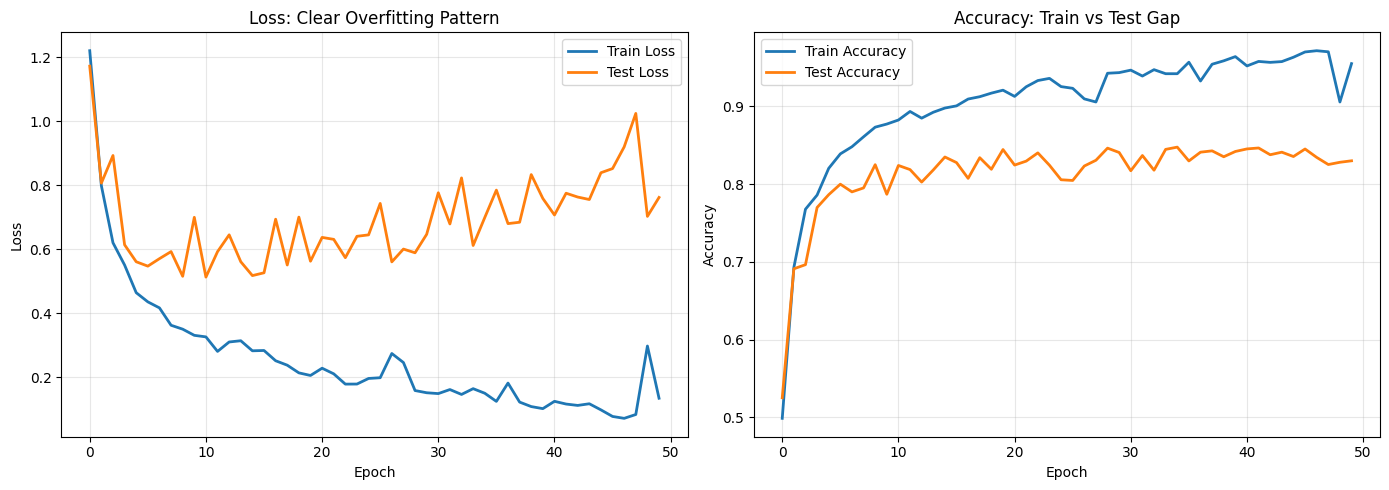


OVERFITTING DEMONSTRATION:
Train Accuracy reaches: 0.9718 (97.2%)
Test Accuracy peaks at: 0.8477 (84.8%)
Final gap (train - test): 0.1251


In [52]:
model_of = OverfittingNeuralNetwork().to(device)
opt_of = torch.optim.Adam(model_of.parameters(), lr=0.001) # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss() # YOUR CODE HERE

# Your experiments, come here

from torch.utils.data import Subset

# Берём только 5000 примеров из 60000
train_subset_indices = list(range(5000))
train_subset = Subset(fmnist_dataset_train, train_subset_indices)

train_loader_small = torch.utils.data.DataLoader(train_subset,
                                                  batch_size=128,
                                                  shuffle=True,
                                                  num_workers=2)

print(f"Train subset size: {len(train_subset)}")
print(f"Test set size: {len(fmnist_dataset_test)}")

train_losses_of, test_losses_of = [], []
train_accs_of, test_accs_of = [], []

num_epochs = 50  # Больше эпох для явного переобучения

for epoch in range(num_epochs):
    #train_loss, train_acc = train_epoch(model, train_loader, opt, loss_func, device)
    train_loss, train_acc = train_epoch(model_of, train_loader_small, opt_of, loss_func, device)
    test_loss, test_acc = evaluate(model_of, test_loader, loss_func, device)

    train_losses_of.append(train_loss)
    test_losses_of.append(test_loss)
    train_accs_of.append(train_acc)
    test_accs_of.append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

print(f'\nFinal Train Accuracy: {train_accs_of[-1]:.4f}')
print(f'Final Test Accuracy: {test_accs_of[-1]:.4f}')
print(f'Overfitting gap: {train_accs_of[-1] - test_accs_of[-1]:.4f}')


# Графики переобучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses_of, label='Train Loss', linewidth=2)
axes[0].plot(test_losses_of, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss: Clear Overfitting Pattern')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs_of, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accs_of, label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy: Train vs Test Gap')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("OVERFITTING DEMONSTRATION:")
print("="*50)
print(f"Train Accuracy reaches: {max(train_accs_of):.4f} ({max(train_accs_of)*100:.1f}%)")
print(f"Test Accuracy peaks at: {max(test_accs_of):.4f} ({max(test_accs_of)*100:.1f}%)")
print(f"Final gap (train - test): {train_accs_of[-1] - test_accs_of[-1]:.4f}")
print("="*50)

<font color = darkblue>
Что видно на графиках:

- <font color = darkblue>train Loss стабильно падает, test Loss после ~10 эпохи стабильно растет;</font>
- <font color = darkblue>train Accuracy растёт, test Accuracy достигает ~82% и стабилизируется</font>

Видны признаки явного переобучения
</font>

### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

In [63]:
class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards

            # Your network structure comes here

            nn.Linear(input_shape, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [64]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 2048]       1,607,680
       BatchNorm1d-3                 [-1, 2048]           4,096
              ReLU-4                 [-1, 2048]               0
           Dropout-5                 [-1, 2048]               0
            Linear-6                 [-1, 1024]       2,098,176
       BatchNorm1d-7                 [-1, 1024]           2,048
              ReLU-8                 [-1, 1024]               0
           Dropout-9                 [-1, 1024]               0
           Linear-10                  [-1, 512]         524,800
      BatchNorm1d-11                  [-1, 512]           1,024
             ReLU-12                  [-1, 512]               0
          Dropout-13                  [-1, 512]               0
           Linear-14                  [

In [ ]:
model_fx = FixedNeuralNetwork().to(device)
opt_fx = torch.optim.Adam(model_fx.parameters(), lr=0.001, weight_decay=1e-4)  # L2 регуляризация # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss() # YOUR CODE HERE

# Your experiments, come here
train_losses_fix, test_losses_fix = [], []
train_accs_fix, test_accs_fix = [], []

num_epochs = 50

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_fx, train_loader_small, opt_fx, loss_func, device)
    test_loss, test_acc = evaluate(model_fx, test_loader, loss_func, device)

    train_losses_fix.append(train_loss)
    test_losses_fix.append(test_loss)
    train_accs_fix.append(train_acc)
    test_accs_fix.append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

print(f'\nFinal Train Accuracy: {train_accs_fix[-1]:.4f}')
print(f'Final Test Accuracy: {test_accs_fix[-1]:.4f}')
print(f'Overfitting gap: {train_accs_fix[-1] - test_accs_fix[-1]:.4f}')


# Сравнительные графики: Task 2 vs Task 3
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss сравнение
axes[0, 0].plot(train_losses_of, label='Train Loss (Overfitting)', linestyle='--', alpha=0.7)
axes[0, 0].plot(test_losses_of, label='Test Loss (Overfitting)', linestyle='--', alpha=0.7)
axes[0, 0].plot(train_losses_fix, label='Train Loss (Fixed)', linewidth=2)
axes[0, 0].plot(test_losses_fix, label='Test Loss (Fixed)', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Comparison: Overfitting vs Fixed')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy сравнение
axes[0, 1].plot(train_accs_of, label='Train Acc (Overfitting)', linestyle='--', alpha=0.7)
axes[0, 1].plot(test_accs_of, label='Test Acc (Overfitting)', linestyle='--', alpha=0.7)
axes[0, 1].plot(train_accs_fix, label='Train Acc (Fixed)', linewidth=2)
axes[0, 1].plot(test_accs_fix, label='Test Acc (Fixed)', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison: Overfitting vs Fixed')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Fixed model только - Loss
axes[1, 0].plot(train_losses_fix, label='Train Loss', linewidth=2, color='blue')
axes[1, 0].plot(test_losses_fix, label='Test Loss', linewidth=2, color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Fixed Model: Loss (with Regularization)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Fixed model только - Accuracy
axes[1, 1].plot(train_accs_fix, label='Train Accuracy', linewidth=2, color='blue')
axes[1, 1].plot(test_accs_fix, label='Test Accuracy', linewidth=2, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Fixed Model: Accuracy (with Regularization)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Итоговое сравнение
print("\n" + "="*60)
print("COMPARISON: OVERFITTING vs FIXED")
print("="*60)
print(f"{'Metric':<25} {'Overfitting':<15} {'Fixed':<15}")
print("-"*60)
print(f"{'Max Train Accuracy':<25} {max(train_accs_of):.4f}          {max(train_accs_fix):.4f}")
print(f"{'Max Test Accuracy':<25} {max(test_accs_of):.4f}          {max(test_accs_fix):.4f}")
print(f"{'Final Train Accuracy':<25} {train_accs_of[-1]:.4f}          {train_accs_fix[-1]:.4f}")
print(f"{'Final Test Accuracy':<25} {test_accs_of[-1]:.4f}          {test_accs_fix[-1]:.4f}")
print(f"{'Final Gap (train-test)':<25} {train_accs_of[-1]-test_accs_of[-1]:.4f}          {train_accs_fix[-1]-test_accs_fix[-1]:.4f}")
print("="*60)


Epoch 10/50: Train Loss: 0.4383, Train Acc: 0.8530, Test Loss: 0.5172, Test Acc: 0.8181
Epoch 20/50: Train Loss: 0.3819, Train Acc: 0.8690, Test Loss: 0.4852, Test Acc: 0.8363


<font color = darkblue>
Что видно на графиках:

- <font color = darkblue>Loss: в Fixed модели Train Loss и Test Loss идут ближе друг к другу;</font>
- <font color = darkblue>Loss: Разрыв между Train и Test значительно меньше - кривые идут почти параллельно;</font>
- <font color = darkblue>регуляризация работает: сеть не может так легко запомнить train-данные, вынуждена учить более общие паттерны</font>

</font>

### Conclusions:
Было продемонстрировано явление переобучения.<br>
Для борьбы с ним были применены техники:

- Dropout - случайно отключает нейроны во время обучения;
- BatchNorm - нормализует активации, действует как неявный регуляризатор;
- Weight Decay - штраф за большие веса.

Эти техники дали заметный результат, значительно снизив эффект переобучения.

**Основные выводы**
1. Переобучение возникает, когда ёмкость модели слишком велика относительно размера обучающих данных
2. Техники регуляризации (Dropout, BatchNorm, L2) эффективно уменьшают переобучение
3. Компромисс: регуляризация немного снижает train accuracy, но улучшает обобщающую способность
4. Мониторинг метрик на train и test необходим для обнаружения переобучения